# CHE1148 - Assignment 1: The Shape of Chemical Data

**Overview:**
This assignment bridges the gap between raw chemical structures and machine learning architectures. We will utilize the Delaney Solubility dataset, specifically evaluating the differences between a standard stratified split and an adversarial split to understand domain shift in chemical space.

**Setup Instructions:**
Run the following cell to install the required chemoinformatics and deep learning libraries, and to pull the dataset directly into the Colab environment.

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
  # Install necessary packages if running in Colab
  !pip install -q torch-geometric rdkit torchinfo
  !pip install git+https://github.com/bp-kelley/descriptastorus

  Cloning https://github.com/bp-kelley/descriptastorus to /tmp/pip-req-build-kxih3_89
  Running command git clone --filter=blob:none --quiet https://github.com/bp-kelley/descriptastorus /tmp/pip-req-build-kxih3_89
  Resolved https://github.com/bp-kelley/descriptastorus to commit 9a190343bcd3cfd35142d378d952613bcac40797
  Preparing metadata (setup.py) ... done


In [ ]:
# Core
import os
import warnings

# Numerical & Visual
import numpy as np
import pandas as pd
import scipy.spatial.distance as sp_dist
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm.auto as tqdm

# Science-y
import rdkit.Chem
import rdkit.Chem.Draw
import rdkit.Chem.rdFingerprintGenerator
import descriptastorus.descriptors.rdDescriptors
import descriptastorus.descriptors.DescriptorGenerator

# Machine Learning
import sklearn.neighbors
import sklearn.metrics
import sklearn.decomposition

# AI & Deep Learning
import torch
import torch.nn
import torch.optim
import torch.optim.lr_scheduler
import torch.utils.data
import torch_geometric as pyg
import torch_geometric.data
import torch_geometric.loader
import torch_geometric.nn
import torch_geometric.utils
import torchinfo

# Reproducibility & Device Configuration
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {DEVICE}")

Active Device: cuda


## Exercise 1: Geometric Properties of High Dimensional Spaces (2 pts)

This exercise aims to build your intuition regarding the geometry of high-dimensional spaces, which are frequently encountered in deep learning, particularly in the context of latent representations. We will explore properties of randomly generated vectors drawn from a normal Gaussian distribution as dimensionality increases.

Inspired on: ["On the Surprising Behavior of Distance Metrics in High Dimensional Space"](https://link.springer.com/chapter/10.1007/3-540-44503-X_27).

### Constants (do not edit)
**Tips**:

* Use `plt.xscale('log')` for plots that use dimensions on the xaxis.
* `dict` is good to collect indivdual results.
* `pd.Dataframe(list[dict])` is good for building a table of results.
*  `sklearn.neighbors` has a fast approximate nearest neighbor algorithm.
*  Additional plots (histograms) can be useful to build better intuition but not required for an answer.

In [ ]:
dimensions = [2, 5, 10, 25 ,50, 100, 250, 500, 1000]
num_vectors = 1000
num_trials = 10 # For stochastic exercises

### 1.a Vector norms (.25 pts)

For each vector dimension:
* Generate sets of random vectors of dimenionality=dimension.
* For each dimension, generate `num_vectors` vectors sampled from a standard normal Gaussian distribution ($\mathcal{N}(0, \mathbf{I})$).
* Calculate the norms of these vectors and compute the mean and standard deviation of these norms.

**Expected output:** Plot of `Dimension` vs `Mean Norm` with errorbars or shaded width using the std.

,Dimension,Mean Norm,Std Norm
0,2,1.237061,0.653373
1,5,2.148911,0.674808
2,10,3.095292,0.689305
3,25,4.943454,0.700118
4,50,7.048339,0.690792
5,100,9.960759,0.711791
6,250,15.816521,0.707115
7,500,22.357106,0.718784
8,1000,31.648614,0.681182


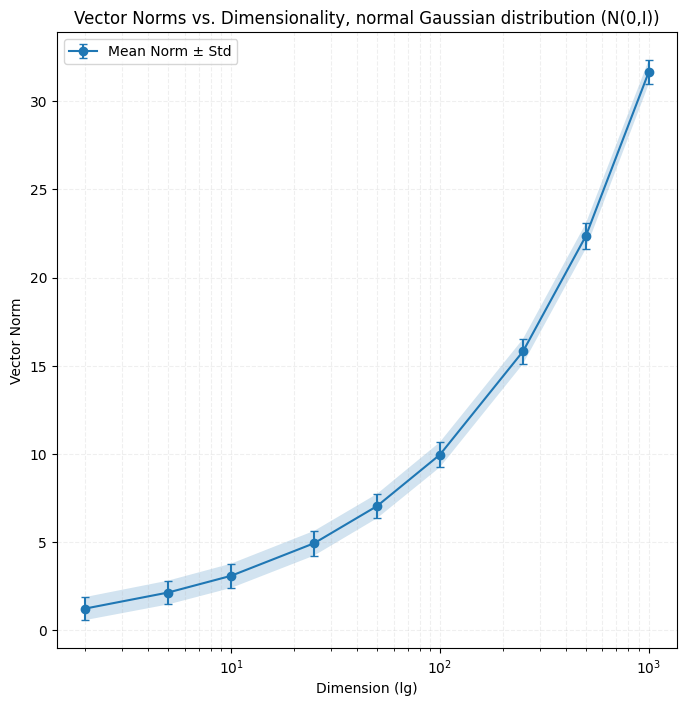

In [ ]:
results = []

for dim in dimensions:
    # Sampled from a standard normal distribution N(0, I)
    vectors = np.random.randn(num_vectors, dim)

    # Calculate L2 norms (Euclidean norms) for each vector
    norms = np.linalg.norm(vectors, axis=1)

    results.append({
        'Dimension': dim,
        'Mean Norm': np.mean(norms),
        'Std Norm': np.std(norms)
    })

# Convert results to DataFrame for easier plotting and check its content
df_norms = pd.DataFrame(results)
display(df_norms)

# Plotting
plt.figure(figsize=(8, 8))
plt.errorbar(df_norms['Dimension'], df_norms['Mean Norm'], yerr=df_norms['Std Norm'],
             fmt='-o', capsize=3, label='Mean Norm ± Std')

# Shading the standard deviation area
plt.fill_between(df_norms['Dimension'],
                 df_norms['Mean Norm'] - df_norms['Std Norm'],
                 df_norms['Mean Norm'] + df_norms['Std Norm'],
                 alpha=0.2)

plt.xscale('log')
plt.xlabel('Dimension (lg)')
plt.ylabel('Vector Norm')
plt.title('Vector Norms vs. Dimensionality, normal Gaussian distribution (N(0,I))')
plt.grid(True, which="both",ls="--", alpha=0.2)
plt.legend()
plt.show()

### 1.b Pairwise distances (.25 pts)

For each dimension in `dimensions`:
* Generate random vectors.
* Calculate pairwise Euclidean and Cosine distances between all generated vectors.
* Compute the mean and standard deviation of these pairwise distances for both metrics.

**Expected output:** Plot of `Dimension` vs `Average Pairwise` with errorbars or shaded width using the std. One for each metric.


,Dimension,Mean Euclidean,Std Euclidean,Mean Cosine,Std Cosine
0,2,1.757692,0.917690,1.000872,0.707578
1,5,3.039121,1.014732,0.999850,0.446622
2,10,4.300353,0.963881,0.999928,0.316147
3,25,7.021766,1.013676,0.999609,0.200008
4,50,9.960054,1.004628,1.000436,0.141244
5,100,14.109909,0.998312,0.999825,0.099872
6,250,22.355941,1.006827,1.000038,0.063230
7,500,31.586007,0.983039,0.999960,0.044732
8,1000,44.670259,0.985920,1.000000,0.031595


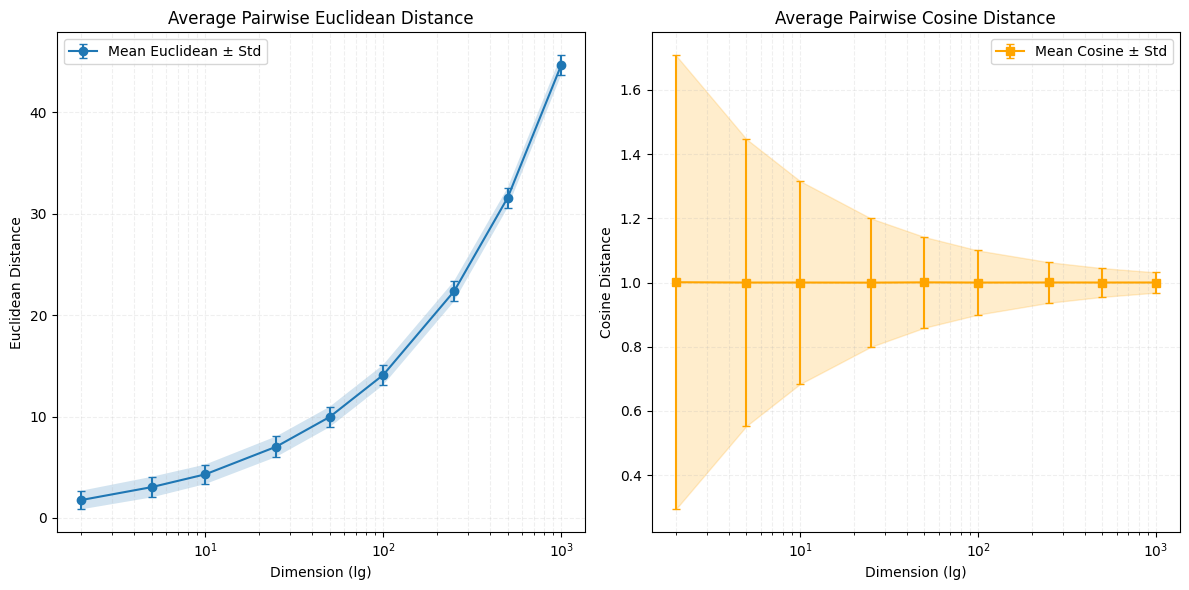

In [ ]:
dist_results = []

for dim in dimensions:
    # Generate vectors sampled from N(0, I)
    vectors = np.random.randn(num_vectors, dim)

    # Calculate condensed pairwise distances
    euc_dist = sp_dist.pdist(vectors, metric='euclidean')
    cos_dist = sp_dist.pdist(vectors, metric='cosine')

    dist_results.append({
        'Dimension': dim,
        'Mean Euclidean': np.mean(euc_dist),
        'Std Euclidean': np.std(euc_dist),
        'Mean Cosine': np.mean(cos_dist),
        'Std Cosine': np.std(cos_dist)
    })

df_dist = pd.DataFrame(dist_results)
display(df_dist)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Euclidean Distances Plot
ax1.errorbar(df_dist['Dimension'], df_dist['Mean Euclidean'], yerr=df_dist['Std Euclidean'],
             fmt='-o', capsize=3, label='Mean Euclidean ± Std')
ax1.fill_between(df_dist['Dimension'],
                 df_dist['Mean Euclidean'] - df_dist['Std Euclidean'],
                 df_dist['Mean Euclidean'] + df_dist['Std Euclidean'], alpha=0.2)
ax1.set_xscale('log')
ax1.set_xlabel('Dimension (lg)')
ax1.set_ylabel('Euclidean Distance')
ax1.set_title('Average Pairwise Euclidean Distance')
ax1.grid(True, which="both", ls="--", alpha=0.2)
ax1.legend()

# Cosine Distances Plot
ax2.errorbar(df_dist['Dimension'], df_dist['Mean Cosine'], yerr=df_dist['Std Cosine'],
             fmt='-s', color='orange', capsize=3, label='Mean Cosine ± Std')
ax2.fill_between(df_dist['Dimension'],
                 df_dist['Mean Cosine'] - df_dist['Std Cosine'],
                 df_dist['Mean Cosine'] + df_dist['Std Cosine'], color='orange', alpha=0.2)
ax2.set_xscale('log')
ax2.set_xlabel('Dimension (lg)')
ax2.set_ylabel('Cosine Distance')
ax2.set_title('Average Pairwise Cosine Distance')
ax2.grid(True, which="both", ls="--", alpha=0.2)
ax2.legend()

plt.tight_layout()
plt.show()

### 1.c Angle Between Random Vectors (.25 pts)

Investigate how the distribution of angles between pairs of randomly generated vectors changes as dimensionality increases.

For each dimension in dimensions:
* Generate `num_vectors` pairs of random vectors.
* Calculate the angle (in degrees) between each pair of vectors.
* Decide if the vectors are "close to orthogonal" (+/- 10 degrees from 90)

**Expected output:** Plot of `Dimension` vs `Percent nearly orthogonal`.

,Dimension,Percent Nearly Orthogonal
0,2,11.8
1,5,24.6
2,10,35.1
3,25,60.3
4,50,76.2
5,100,92.1
6,250,99.6
7,500,100.0
8,1000,100.0


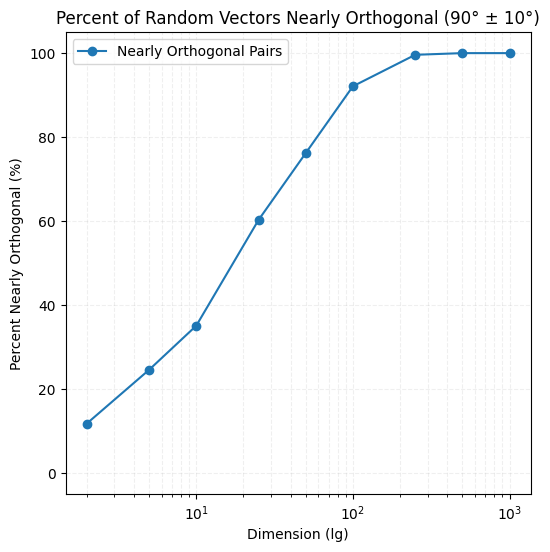

In [ ]:
angle_results = []

for dim in dimensions:
    # Generate two sets of vectors to form pairs
    v1 = np.random.randn(num_vectors, dim)
    v2 = np.random.randn(num_vectors, dim)

    # Calculate dot products and norms for angle calculation
    # cos(theta) = (v1 * v2) / (||v1|| * ||v2||)
    dot_product = np.sum(v1 * v2, axis=1)
    norms_v1 = np.linalg.norm(v1, axis=1)
    norms_v2 = np.linalg.norm(v2, axis=1)

    cos_theta = dot_product / (norms_v1 * norms_v2)
    # Clip values to avoid floating point errors outside [-1, 1]
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    # Convert radians to degrees
    angles_deg = np.degrees(np.arccos(cos_theta))

    # Check if nearly orthogonal (80° to 100°)
    is_orthogonal = (angles_deg >= 80) & (angles_deg <= 100)
    percent_ortho = np.mean(is_orthogonal) * 100

    angle_results.append({
        'Dimension': dim,
        'Percent Nearly Orthogonal': percent_ortho
    })

df_angles = pd.DataFrame(angle_results)
display(df_angles)

# Plotting
plt.figure(figsize=(6, 6))
plt.plot(df_angles['Dimension'], df_angles['Percent Nearly Orthogonal'], '-o', label='Nearly Orthogonal Pairs')

plt.xscale('log')
plt.xlabel('Dimension (lg)')
plt.ylabel('Percent Nearly Orthogonal (%)')
plt.title('Percent of Random Vectors Nearly Orthogonal (90° ± 10°)')
plt.grid(True, which="both", ls="--", alpha=0.2)
plt.ylim(-5, 105)
plt.legend()
plt.show()

### 1.d Nearest Neighbors (.25 pts)


For each dimension in dimensions, and for num_trials trials:
* Generate a random query vector.
* Find its 5 nearest neighbors within the set of num_vectors generated vectors.
* Record the distances (euclidean, cosine) to the first nearest neighbor.
* Compute the average and standard deviation of these distances across trials for each dimension and metric.

**Expected output:** Plot of `Dimension` vs `Distance to nearest neighbor` with errorbars or shaded width using the std. One for each metric.

,Dimension,Mean Euc NN,Std Euc NN,Mean Cos NN,Std Cos NN
0,2,0.149462,0.111911,0.000004,0.000005
1,5,0.781600,0.281333,0.028329,0.016346
2,10,1.761805,0.495439,0.173224,0.046743
3,25,4.315638,0.484200,0.384061,0.039270
4,50,7.320969,0.304194,0.572123,0.019846
5,100,11.493947,0.372607,0.683626,0.006282
6,250,19.701343,0.405559,0.795427,0.021138
7,500,28.740916,0.588069,0.860722,0.008413
8,1000,41.904521,0.549801,0.898523,0.011404


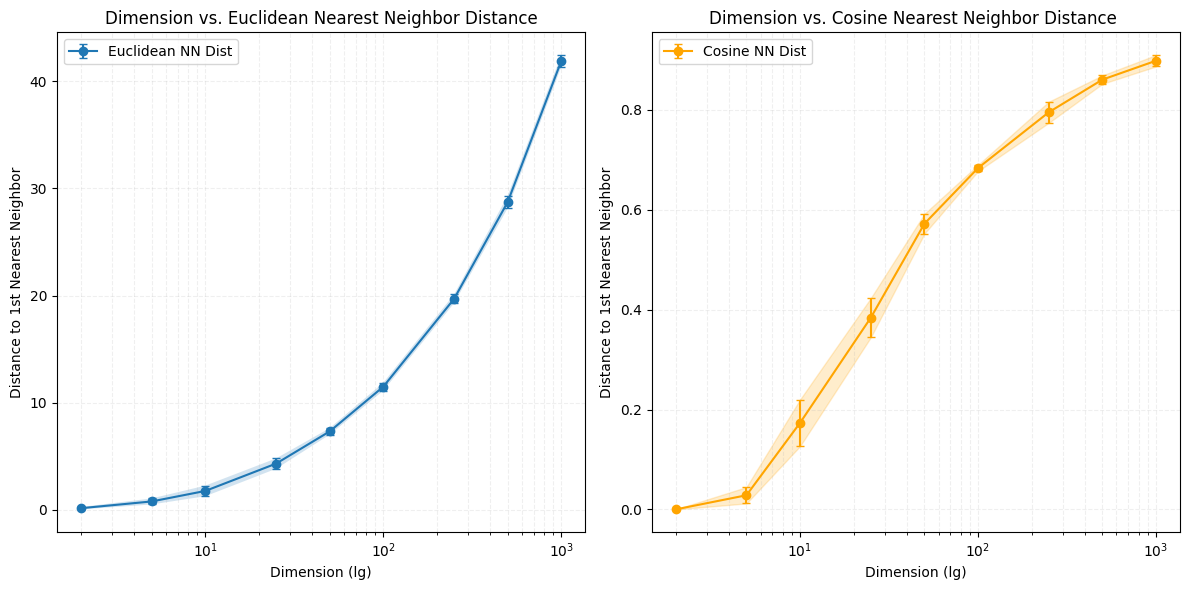

In [ ]:
nn_results = []

for dim in dimensions:
    euc_nn_distances = []
    cos_nn_distances = []

    for _ in range(num_trials):
        # Generate set of vectors and a single random query vector
        reference_vectors = np.random.randn(num_vectors, dim)
        query_vector = np.random.randn(1, dim)

        # Find 5 nearest neighbors

        # Using Euclidean metric
        nbrs_euc = sklearn.neighbors.NearestNeighbors(n_neighbors=5, metric='euclidean').fit(reference_vectors)
        distances_euc, _ = nbrs_euc.kneighbors(query_vector)
        euc_nn_distances.append(distances_euc[0][0])

        # Using Cosine metric
        nbrs_cos = sklearn.neighbors.NearestNeighbors(n_neighbors=5, metric='cosine').fit(reference_vectors)
        distances_cos, _ = nbrs_cos.kneighbors(query_vector)
        cos_nn_distances.append(distances_cos[0][0])

    # Compute mean and std across trials
    nn_results.append({
        'Dimension': dim,
        'Mean Euc NN': np.mean(euc_nn_distances),
        'Std Euc NN': np.std(euc_nn_distances),
        'Mean Cos NN': np.mean(cos_nn_distances),
        'Std Cos NN': np.std(cos_nn_distances)
    })

df_nn = pd.DataFrame(nn_results)
display(df_nn)

# Expected Output: Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Euclidean Plot
ax1.errorbar(df_nn['Dimension'], df_nn['Mean Euc NN'], yerr=df_nn['Std Euc NN'], fmt='-o', capsize=3, label='Euclidean NN Dist')
ax1.fill_between(df_nn['Dimension'], df_nn['Mean Euc NN'] - df_nn['Std Euc NN'], df_nn['Mean Euc NN'] + df_nn['Std Euc NN'], alpha=0.2)
ax1.set_xscale('log')
ax1.set_xlabel('Dimension (lg)')
ax1.set_ylabel('Distance to 1st Nearest Neighbor')
ax1.set_title('Dimension vs. Euclidean Nearest Neighbor Distance')
ax1.grid(True, which="both", ls="--", alpha=0.2)
ax1.legend()

# Cosine Plot
ax2.errorbar(df_nn['Dimension'], df_nn['Mean Cos NN'], yerr=df_nn['Std Cos NN'], fmt='-o', color='orange', capsize=3, label='Cosine NN Dist')
ax2.fill_between(df_nn['Dimension'], df_nn['Mean Cos NN'] - df_nn['Std Cos NN'], df_nn['Mean Cos NN'] + df_nn['Std Cos NN'], color='orange', alpha=0.2)
ax2.set_xscale('log')
ax2.set_xlabel('Dimension (lg)')
ax2.set_ylabel('Distance to 1st Nearest Neighbor')
ax2.set_title('Dimension vs. Cosine Nearest Neighbor Distance ')
ax2.grid(True, which="both", ls="--", alpha=0.2)
ax2.legend()

plt.tight_layout()
plt.show()

### 1.e Summarize and reflect on the results (1 pts)

Summarize the results from previous exercises, make reference to the plots when making your points. You should reference at least once each plot in your writting.

Some questions you will want to address:

* We generated random normal distributed vectors, is this a reasonable assumption when working neural network activations? *
* Why? When does this assumption break?
* What can you intuite about the "data manifold" (learned geometry of data)?
* If you wanted to interpolate between two vector, where the path lies close to data, how would you do it?
* How probable are zero-vectors?
* Which distance would you use? (and why?)
* How is this exercise relevant to modern Chemical Data?

**Answer for 1e**

# 1e.1 Summarize the outputs above:

Figure 1a shows the L2 norm increases with the demension increasing, and its value is approximatedly equal to the square root of the dimension number. Such as when L2 norm is 10, the coorespending dimension is 100. And the standard deviations remain constant, around 0.7, even though the dimension increases a lot.

Figure 1b, these two figures show that: the average Euclidean distance between any two random points increases as the dimension numnber increasing, while the variance keep constant around 1, indicating any two points are at the similar Euclidean distance to each other. For the Cosine distance, the mean approaches 1, and variance shrinks with dimension increasing, indicating vectors are almost orthogonal within high dimension space.

Figure 1c, the percentage of orthogonal increases with dimension increasing. Almost very two vectors are orthogonal to each other.

Figure 1d shows the Euclidean distance nearest neighbor increases with dimension increasing, indicating that distance between every two vectors would increas due to the dimension increasing. And also shows that, Cosine distance of nearest neighbor increases from 0 to 1, recomfirming that high dimension would cause every two vectors become orthogonal.

# 1e.2 Considerations from the above outputs:

**Is it a reasonable assumption to use random normal distributed vectors when working with neural network activations?**

Yes. For initializing weights at the very beginning of training, we could use Xavier method which follow random normally distribution fro initializing weights.

**When does this assumption break?**
Immediately after going through non-linear activation functions. For example, a ReLU activation drops all negative values, completely destroying its original distributions. Furthermore, as a network learns, these weights would become more structured which is corresponding to training set, leading to far way from random Gaussian distribution.

**What can you intuite about the "data manifold" (learned geometry of data)?**

When we use neural network to learn the dataset, the information would change from relative high dimension to relative low dimension. Besides, the orginal dataset contains a lot of information, so they are not independed random distributed.

**If you wanted to interpolate between two vectors, where the path lies close to data, how would you do it?**

Autoencoder is a good choice, becasue it learns and knows the data pattern, which can interpolate data without disturbing original structure.

**How probable are zero-vectors?**

Extremely improbable. As shown in 1.a, the norm of a random vector strongly concentrates around $\sqrt{d}$. In high dimensions, virtually all of the volume is located in a thin shell far away from the origin.

**Which distance would you use? (and why?)**
Cosine distance is preferred in high-dimensional spaces. Euclidean distances between any two random points become large with dimension increasing. But, Cosine distance isolates the angle of the vectors, effectively normalizing out the massive lengths, containing the actual semantic meaning of the representation.

**How is this exercise relevant to modern Chemical Data?**
The modern Chemical Data typically uses high-dimensional data, such as 1024-bit Morgan Fingerprints, or continuous latent vectors from GNN. Within these high-dimensional spaces, each two random vectors have intrinsiclly high Euclidean distance, losing its comparative value. So, if we want to measure chemical similarity, we need specific metrics, such as Cosine distance or Jaccard/Tanimoto similarity.



# Preamble for exercises (2-4)
## Setup data splits

In [ ]:
# Data Ingestion
url = "https://raw.githubusercontent.com/chemcognition-lab/CHE1148/main/data/delaney/delaney-solubility.csv"
df = pd.read_csv(url)

print(df.columns)
train_strat_df = df[df['split_stratified'] == 'train'].copy()
test_strat_df = df[df['split_stratified'] == 'test'].copy()
train_adv_df = df[df['split_adversarial'] == 'train'].copy()
test_adv_df = df[df['split_adversarial'] == 'test'].copy()

print(f"Stratified Test Set: {len(test_strat_df)} molecules")
print(f"Adversarial Test Set: {len(test_adv_df)} molecules")

Index(['Compound ID', 'ESOL predicted log solubility in mols per litre',
       'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
       'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'smiles', 'split_random',
       'strat_bin', 'split_stratified', 'split_adversarial'],
      dtype='object')
Stratified Test Set: 226 molecules
Adversarial Test Set: 274 molecules


## Important columns

In [ ]:
Y_COL = 'ESOL predicted log solubility in mols per litre'
SMI_COL = 'smiles'

# Exercise 2: Activity Cliffs (SALI) 1.5pts

Chemical space is discrete and highly non-linear. Frequently, a minute change to a molecular structure (e.g., adding a single functional group or changing a stereocenter) can drastically alter its physical properties. This abrupt change in activity/property between structurally similar molecules is known as an "Activity Cliff."

We quantify this using the Structure-Activity Landscape Index (SALI):
$$SALI_{i,j} = \frac{|y_i - y_j|}{1 - similarity_{i,j}}$$

**Your Task:**
Using the `train_strat_df` split, we have already generated the Morgan Fingerprints (`fps_matrix`) and filtered valid targets (`y_valid`) for you in the provided setup cell. You must implement the rest:

1. Compute the pairwise Jaccard distance between all fingerprints in `fps_matrix`. *(Note: Jaccard distance on bit vectors is mathematically equivalent to $1 - similarity$).*
2. Compute the pairwise Euclidean distance between their actual log solubility values in `y_valid`.
3. Calculate the SALI matrix and extract the indices of the **top 5 pairs** of molecules with the highest scores. Print these top 5 scores alongside their $\Delta$ LogS.
4. Visualize the absolute steepest cliff (the #1 pair) by drawing the two molecules side-by-side using `rdkit.Chem.Draw.MolsToGridImage`.

**Hints:**
* `scipy.spatial.distance.pdist(..., metric='jaccard')` calculates the condensed pairwise distance matrix efficiently.
* `scipy.spatial.distance.pdist(..., metric='euclidean')` works identically for the continuous solubility values.
* `scipy.spatial.distance.squareform()` converts a condensed 1D distance array back into a readable 2D matrix.
* To avoid grabbing duplicate pairs (e.g., Mol A vs Mol B and Mol B vs Mol A) or self-comparisons (Mol A vs Mol A) when finding the top scores, consider using `numpy.triu(..., k=1)` to isolate only the upper triangle of your 2D SALI matrix.

**Expected Output:**
* **[Code]** A flat script calculating the SALI matrix, printing the top 5 pairs, and displaying the grid image.
* **[Graph]** A 2D grid image rendering the #1 steepest cliff pair.
* **[Short Answer]** A 1-2 sentence chemical hypothesis explaining the solubility shift.

## Provided code

In [ ]:
# Fingerprint Hyperparameters
FP_RADIUS = 2
FP_SIZE = 1024
EPSILON = 1e-6 # To prevent division by zero in SALI calculations

In [ ]:
mfpgen = rdkit.Chem.rdFingerprintGenerator.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_SIZE)

smiles_list: list[str] = train_strat_df[SMI_COL].tolist()
y_vals: np.ndarray = train_strat_df[Y_COL].values

fps: list[np.ndarray] = []
valid_idx: list[int] = []

for idx, smi in enumerate(smiles_list):
    mol = rdkit.Chem.MolFromSmiles(smi)
    if mol is not None:
        fps.append(mfpgen.GetFingerprintAsNumPy(mol))
        valid_idx.append(idx)

# Students will use these two arrays for their SALI calculations
fps_matrix: np.ndarray = np.array(fps)
y_valid: np.ndarray = y_vals[valid_idx]

## Your work
**Expected Output:**
* **[Code]** A flat execution script calculating the SALI matrix, printing the top 5 pairs, and displaying the grid image.
* **[Graph]** A 2D grid image rendering the #1 steepest cliff pair.

,Rank,Mol 1 Index,Mol 1 SMILES,Mol 2 Index,Mol 2 SMILES,Euclidean Dist (Solubility),Jaccard Dist (Structure),SALI Score
0,1,236,CCCCCCCCCCCCCCCCCCCCCCCCCC,598,CCCCCCC,6.7320,0.0000,6732000.0
1,2,236,CCCCCCCCCCCCCCCCCCCCCCCCCC,612,CCCCCCCC,6.3780,0.0000,6378000.0
2,3,236,CCCCCCCCCCCCCCCCCCCCCCCCCC,583,CCCCCCCCC,6.0240,0.0000,6024000.0
3,4,598,CCCCCCC,876,CCCCCCCCCCCCCCCCCCCC,4.6060,0.0000,4606000.0
4,5,612,CCCCCCCC,876,CCCCCCCCCCCCCCCCCCCC,4.2520,0.0000,4252000.0


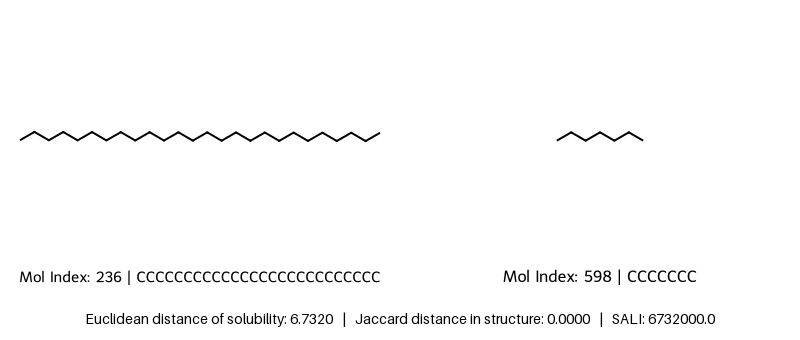

In [ ]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

# Compute pairwise Jaccard distance
jaccard_dist = sp_dist.pdist(fps_matrix, metric='jaccard')

# Compute pairwise Euclidean distance for Log Solubility
y_valid_reshaped = y_valid.reshape(-1, 1)
euclidean_dist = sp_dist.pdist(y_valid_reshaped, metric='euclidean')

# Calculate SALI
# Adding EPSILON to prevent division by zero
sali_condensed = euclidean_dist / (jaccard_dist + EPSILON)

# Convert to square form and extract upper triangle to avoid duplicates/self-comparisons
sali_matrix = sp_dist.squareform(sali_condensed)
sali_matrix_upper = np.triu(sali_matrix, k=1)

# Get square forms for euc and jac distances to easily access pairwise values
euc_matrix = sp_dist.squareform(euclidean_dist)
jac_matrix = sp_dist.squareform(jaccard_dist)

# Get top 5 indices
flat_indices = np.argsort(sali_matrix_upper.flatten())[::-1][:5]
top5_idx_pairs = [np.unravel_index(idx, sali_matrix_upper.shape) for idx in flat_indices]

# Collect top 5 pairs into a DataFrame
top5_data = []
for rank, (i, j) in enumerate(top5_idx_pairs, 1):
    sali_score = sali_matrix[i, j]
    euc_d = euc_matrix[i, j]
    jac_d = jac_matrix[i, j]
    smi_i = smiles_list[valid_idx[i]]
    smi_j = smiles_list[valid_idx[j]]
    top5_data.append({
        'Rank': rank,
        'Mol 1 Index': i,
        'Mol 1 SMILES': smi_i,
        'Mol 2 Index': j,
        'Mol 2 SMILES': smi_j,
        'Euclidean Dist (Solubility)': f"{euc_d:.4f}",
        'Jaccard Dist (Structure)': f"{jac_d:.4f}",
        'SALI Score': f"{sali_score:.1f}"
    })

df_top5_sali = pd.DataFrame(top5_data)
display(df_top5_sali)

# Visualize the steepest cliff (#1 pair)
top_i, top_j = top5_idx_pairs[0]

# Map indices back to original smiles_list using valid_idx
smi_i = smiles_list[valid_idx[top_i]]
smi_j = smiles_list[valid_idx[top_j]]

top_euc = euc_matrix[top_i, top_j]
top_jac = jac_matrix[top_i, top_j]
top_sali = sali_matrix[top_i, top_j]

mol_i = rdkit.Chem.MolFromSmiles(smi_i)
mol_j = rdkit.Chem.MolFromSmiles(smi_j)

img = rdkit.Chem.Draw.MolsToGridImage(
    [mol_i, mol_j],
    legends=[
        f"Mol Index: {top_i} | {smi_i}",
        f"Mol Index: {top_j} | {smi_j}"
    ],
    molsPerRow=2,
    subImgSize=(400, 300),
    returnPNG=False
)

text = f"Euclidean distance of solubility: {top_euc:.4f}   |   Jaccard distance in structure: {top_jac:.4f}   |   SALI: {top_sali:.1f}"

width, height = img.size
new_height = height + 40
new_img = Image.new("RGB", (width, new_height), "white")
new_img.paste(img, (0, 0))

draw = ImageDraw.Draw(new_img)

# Try loading a larger default font
try:
    font = ImageFont.load_default(size=14)
except TypeError:
    font = ImageFont.load_default()

# Get text width to center it
try:
    text_width = draw.textlength(text, font=font)
except AttributeError:
    # Fallback for older PIL versions
    text_width, _ = draw.textsize(text, font=font)

text_x = (width - text_width) / 2
text_y = height + 10

draw.text((text_x, text_y), text, fill="black", font=font)

display(new_img)


* **[Short Answer]** Below your code cell, add a Markdown cell with a 1-2 sentence chemical hypothesis explaining *why* the specific structural difference between these two molecules caused such a massive shift in solubility.

**Chemical Hypothesis:**

The top 1 pair of SALI value is between two linear alkanes (heptane and hexacosane), which have extremely different chain lengths.
Their Jaccard distance is almost 0 due to highly similar local structure (FP_RADIUS = 2) and repearting -CH2- groups. But, they have very different molecular weights which cause large difference on ESOL predicted solubilities.

# Exercise 3: Cramming Challenge on Solubility (GraphNets) - 2pts

Standard machine learning evaluation often ignores computational efficiency and the reality of domain shifts. In this challenge, we are using the **Adversarial Split**. Unlike the stratified split, the adversarial split tests how well the model generalizes to molecules that are structurally distinct from the training set.

You will implement a **GraphNets** architecture using PyTorch Geometric's `MetaLayer`. To make stacking multiple layers easy, we will use a "preprocessor" approach: passing the initial node, edge, and global features through `LazyLinear` layers to project them to a consistent hidden dimension before message passing.

**The Grading Threshold & Competition:**
You are strictly limited to **50 epochs** of training. Brute-force training without optimization will fail.
* **Full Marks:** You must achieve a Test $R^2$ strictly greater than **0.70** on the adversarial test set.
* **Bonus:** The top 3 students with the absolute highest $R^2$ score will receive **+1 Bonus Point**.

**Your Task:**
1. Review the provided robust featurizer and the 2-layer `GraphNets` architecture. Notice how the global tensor `u` is seeded as zeros.
2. Review the provided pure functions for `predict` and `evaluate_metrics`.
3. Implement a flat training loop utilizing `tqdm.auto` to track progress.
4. **Crucial:** Because we use `torch.nn.LazyLinear` for the preprocessors, you must perform a single "dummy" forward pass with a batch of data to initialize the weight matrices *before* passing the model parameters to your optimizer.
5. You must utilize learning rate scheduling (`OneCycleLR`) and gradient clipping to maximize feature extraction rapidly within the tight epoch limit.
6. In your loop, decouple inference from training: iterate through the `test_loader`, utilize the `predict` function to accumulate predictions, score them using `evaluate_metrics`, and append the results to a tracking dictionary.
7. **Visualize your convergence:** After exporting your tracked metrics to a `pandas.DataFrame`, plot the training curves for both Test MAE and Test $R^2$.

**Expected Output:**
* **[Code]** The top-to-bottom training execution block, exporting a final `pandas.DataFrame`.
* **[Graph]** Flat, single-axis plots displaying the progression curves for $R^2$ and MAE.
* **[Text]** A short bulleted list suggesting 2-3 structural changes to the architecture/features that could push the $R^2$ even higher.

## Provided code
### Smiles to graph tensorizer + dataloaders

In [ ]:
UNIQ_ATOMS = ['Br', 'C', 'Cl', 'F', 'I', 'N', 'O', 'P', 'S']
EDGE_DIM = 7

def onek_encoding_unk(value: object, choices: list[object]) -> list[float]:
    """Create a one-hot encoding with the last index reserved for unknown values."""
    encoding = [0.0] * (len(choices) + 1)
    index = choices.index(value) if value in choices else -1
    encoding[index] = 1.0
    return encoding

def atom_features(atom: rdkit.Chem.rdchem.Atom) -> list[float]:
    """Extract essential atom features using a defined symbol vocabulary."""
    features = (
        # 1. Atom type (Symbol mapped to UNIQ_ATOMS)
        onek_encoding_unk(atom.GetSymbol(), UNIQ_ATOMS)
        # 2. Degree (Number of directly bonded neighbors)
        + onek_encoding_unk(atom.GetTotalDegree(), [0, 1, 2, 3, 4, 5])
        # 3. Formal Charge (Crucial electronic property)
        + onek_encoding_unk(atom.GetFormalCharge(), [-1, -2, 1, 2, 0])
        # 4. Number of Implicit/Explicit Hydrogens
        + onek_encoding_unk(int(atom.GetTotalNumHs()), [0, 1, 2, 3, 4])
        # 5. Hybridization (Provides 3D geometric hints to a 2D graph)
        + onek_encoding_unk(
            atom.GetHybridization(),
            [
                rdkit.Chem.rdchem.HybridizationType.SP,
                rdkit.Chem.rdchem.HybridizationType.SP2,
                rdkit.Chem.rdchem.HybridizationType.SP3,
                rdkit.Chem.rdchem.HybridizationType.SP3D,
                rdkit.Chem.rdchem.HybridizationType.SP3D2
            ]
        )
        # 6. Aromaticity (Boolean flag)
        + [1.0 if atom.GetIsAromatic() else 0.0]
    )
    return features

def bond_features(bond: rdkit.Chem.rdchem.Bond | None) -> list[float]:
    """Extract essential bond features without stereochemistry."""
    bond_types = [
        rdkit.Chem.rdchem.BondType.SINGLE,
        rdkit.Chem.rdchem.BondType.DOUBLE,
        rdkit.Chem.rdchem.BondType.TRIPLE,
        rdkit.Chem.rdchem.BondType.AROMATIC,
    ]

    if bond is None:
        # Handles isolated nodes or virtual edges: [4 zeros for known types] + [1.0 for unknown] + [0.0, 0.0]
        return [0.0] * len(bond_types) + [1.0, 0.0, 0.0]

    features = (
        # 1. Bond Type
        onek_encoding_unk(bond.GetBondType(), bond_types)
        # 2. Conjugation (Boolean)
        + [float(bond.GetIsConjugated())]
        # 3. Ring Status (Boolean)
        + [float(bond.IsInRing())]
    )
    return features

def smiles_to_graph(smiles: str, y_val: float) -> torch_geometric.data.Data | None:
    mol = rdkit.Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    a_feats = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float32)

    b_indices, b_feats = [], []
    for b in mol.GetBonds():
        i = b.GetBeginAtomIdx()
        j = b.GetEndAtomIdx()
        feats = bond_features(b)
        b_indices += [[i, j], [j, i]]
        b_feats += [feats, feats]

    b_index = torch.tensor(b_indices, dtype=torch.long).t().view(2, -1) if b_indices else torch.empty((2, 0), dtype=torch.long)
    b_feats = torch.tensor(b_feats, dtype=torch.float32) if b_feats else torch.empty((0, EDGE_DIM), dtype=torch.float32)

    if b_index.numel() > 0:
        perm = (b_index[0] * a_feats.size(0) + b_index[1]).argsort()
        b_index, b_feats = b_index[:, perm], b_feats[perm]

    y = torch.tensor([[y_val]], dtype=torch.float32)
    u = torch.zeros((1, 1), dtype=torch.float32)

    return torch_geometric.data.Data(x=a_feats, edge_index=b_index, edge_attr=b_feats, y=y, u=u)


Dataloaders

In [ ]:
BATCH_SIZE = 128
train_adv_graphs: list[torch_geometric.data.Data] = [g for g in (smiles_to_graph(s, y) for s, y in zip(train_adv_df[SMI_COL], train_adv_df[Y_COL])) if g is not None]
test_adv_graphs: list[torch_geometric.data.Data] = [g for g in (smiles_to_graph(s, y) for s, y in zip(test_adv_df[SMI_COL], test_adv_df[Y_COL])) if g is not None]

train_loader = torch_geometric.loader.DataLoader(train_adv_graphs, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch_geometric.loader.DataLoader(test_adv_graphs, batch_size=BATCH_SIZE, shuffle=False)

### Basics GraphNets

In [ ]:
class MLP(torch.nn.Module):
    def __init__(self, in_dim: int, out_dim: int) -> None:
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_dim, out_dim),
            # BatchNorm normalizes the outputs before ReLU, which stabilizes training, prevents dead neurons, allows higher learning rates, and acts as a regularizer.
            torch.nn.BatchNorm1d(out_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(out_dim, out_dim)
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

class EdgeModel(torch.nn.Module):
    def __init__(self, dim: int) -> None:
        super().__init__()
        self.mlp = MLP(4 * dim, dim)

    def forward(self, src: torch.Tensor, dest: torch.Tensor, edge_attr: torch.Tensor, u: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        out = torch.cat([src, dest, edge_attr, u[batch]], dim=1)
        return self.mlp(out)

class NodeModel(torch.nn.Module):
    def __init__(self, dim: int) -> None:
        super().__init__()
        self.mlp = MLP(3 * dim, dim)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor, u: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        _, col = edge_index
        aggr_edges = torch_geometric.utils.scatter(edge_attr, col, dim=0, dim_size=x.size(0), reduce='mean')
        out = torch.cat([x, aggr_edges, u[batch]], dim=1)
        return self.mlp(out)

class GlobalModel(torch.nn.Module):
    def __init__(self, dim: int) -> None:
        super().__init__()
        self.mlp = MLP(2 * dim, dim)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor, u: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        aggr_nodes = torch_geometric.utils.scatter(x, batch, dim=0, dim_size=u.size(0), reduce='mean')
        out = torch.cat([u, aggr_nodes], dim=1)
        return self.mlp(out)

class GraphNets(torch.nn.Module):
    def __init__(self, dim: int) -> None:
        super().__init__()
        # LazyLinear infers the input dimension automatically on the first forward pass
        self.node_prep = torch.nn.LazyLinear(dim)
        self.edge_prep = torch.nn.LazyLinear(dim)
        self.global_prep = torch.nn.LazyLinear(dim)

        self.layer1 = torch_geometric.nn.MetaLayer(EdgeModel(dim), NodeModel(dim), GlobalModel(dim))
        self.layer2 = torch_geometric.nn.MetaLayer(EdgeModel(dim), NodeModel(dim), GlobalModel(dim))

        self.readout = torch.nn.Linear(dim, 1)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor, u: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        x = self.node_prep(x)
        edge_attr = self.edge_prep(edge_attr)
        u = self.global_prep(u)

        x, edge_attr, u = self.layer1(x, edge_index, edge_attr, u, batch)
        x, edge_attr, u = self.layer2(x, edge_index, edge_attr, u, batch)

        return self.readout(u)


Example usage

In [ ]:
HIDDEN_DIM = 64
model = GraphNets(dim=HIDDEN_DIM).to(DEVICE)

# Dummy forward pass to initialize LazyLinear weights before passing to optimizer
sample_batch = next(iter(train_loader)).to(DEVICE)
_ = model(sample_batch.x, sample_batch.edge_index, sample_batch.edge_attr, sample_batch.u, sample_batch.batch)

### Inference & Evaluation functions

In [ ]:
def predict(model: torch.nn.Module, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor, u: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
    model.eval()
    with torch.no_grad():
        out: torch.Tensor = model(x, edge_index, edge_attr, u, batch)
    return out

def evaluate_metrics(preds: torch.Tensor, targets: torch.Tensor) -> dict[str, float]:
    preds_np: np.ndarray = preds.detach().cpu().numpy()
    targets_np: np.ndarray = targets.detach().cpu().numpy()

    return {
        'test_mae': float(sklearn.metrics.mean_absolute_error(targets_np, preds_np)),
        'test_r2': float(sklearn.metrics.r2_score(targets_np, preds_np))
    }

## Your work
**Expected Output:**
* **[Code]** The top-to-bottom training execution block, exporting a final `pandas.DataFrame`.
* **[Graph]** Flat, single-axis plots displaying the progression curves for $R^2$ and MAE.
* **[Text]** A short bulleted list suggesting 2-3 structural changes to the architecture/features that could push the $R^2$ even higher.


In [ ]:
# Instantiate the model for summary
summary_model = GraphNets(dim=HIDDEN_DIM).to(DEVICE)

# Get a dummy batch to initialize the LazyLinear layers
dummy_batch = next(iter(train_loader)).to(DEVICE)

# Perform a forward pass to initialize the dimensions
_ = summary_model(dummy_batch.x, dummy_batch.edge_index, dummy_batch.edge_attr, dummy_batch.u, dummy_batch.batch)

# Print the model summary
torchinfo.summary(
    summary_model,
    input_data=[
        dummy_batch.x,
        dummy_batch.edge_index,
        dummy_batch.edge_attr,
        dummy_batch.u,
        dummy_batch.batch,
    ],
)

Layer (type:depth-idx)                        Output Shape              Param #
GraphNets                                     [128, 1]                  --
├─Linear: 1-1                                 [1884, 64]                2,368
├─Linear: 1-2                                 [3950, 64]                512
├─Linear: 1-3                                 [128, 64]                 128
├─MetaLayer: 1-4                              [1884, 64]                --
│    └─EdgeModel: 2-1                         [3950, 64]                --
│    │    └─MLP: 3-1                          [3950, 64]                20,736
│    └─NodeModel: 2-2                         [1884, 64]                --
│    │    └─MLP: 3-2                          [1884, 64]                16,640
│    └─GlobalModel: 2-3                       [128, 64]                 --
│    │    └─MLP: 3-3                          [128, 64]                 12,544
├─MetaLayer: 1-5                              [1884, 64]                --
│  

Starting Grid Search over 9 configurations...

Testing LR_MAX: 0.001 | Weight Decay: 0.0001


Training LR=0.001, WD=0.0001:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping triggered at epoch 41 (Best R2: 0.6128)
-> Best Test R2: 0.6128 | Test MAE: 0.5484

Testing LR_MAX: 0.001 | Weight Decay: 0.0005


Training LR=0.001, WD=0.0005:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping triggered at epoch 42 (Best R2: 0.6094)
-> Best Test R2: 0.6094 | Test MAE: 0.5772

Testing LR_MAX: 0.001 | Weight Decay: 0.001


...

-> Best Test R2: 0.6053 | Test MAE: 0.4994

Testing LR_MAX: 0.01 | Weight Decay: 0.0005


Training LR=0.01, WD=0.0005:   0%|          | 0/50 [00:00<?, ?it/s]

-> Best Test R2: 0.6177 | Test MAE: 0.4824

Testing LR_MAX: 0.01 | Weight Decay: 0.001


Training LR=0.01, WD=0.001:   0%|          | 0/50 [00:00<?, ?it/s]

-> Best Test R2: 0.6976 | Test MAE: 0.4733

========== GRID SEARCH COMPLETE ==========
BEST CONFIG: LR_MAX=0.005, Weight Decay=0.0001
BEST TEST R2: 0.7332



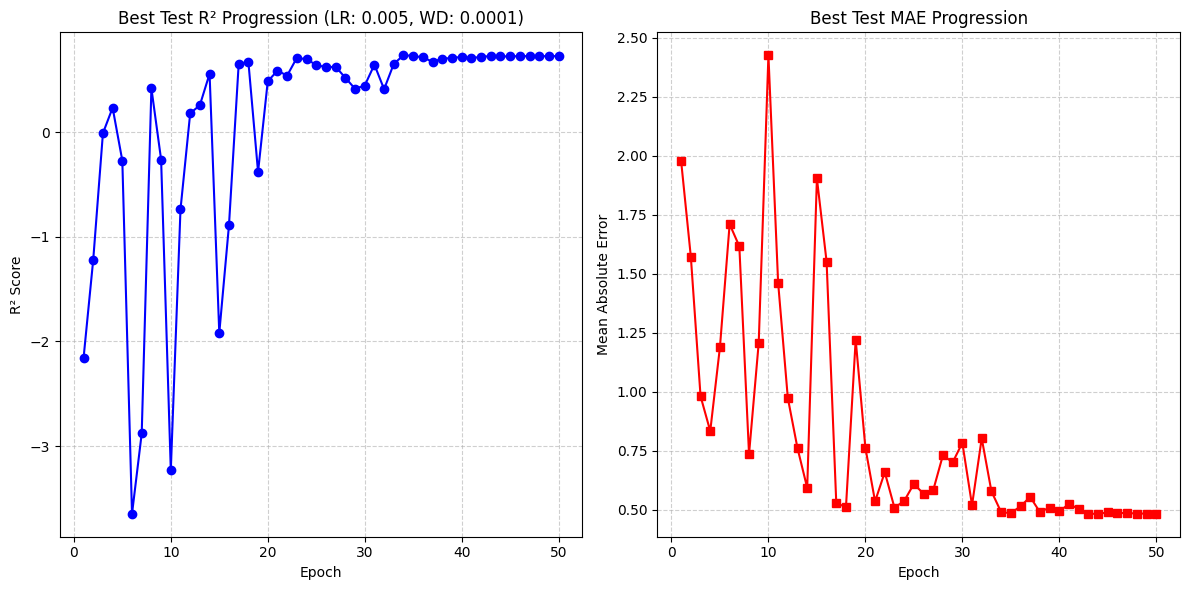

In [ ]:
# Strategies of current code:
# 1. Hyperparameter tuning: 'learning rate' and 'weight decay'
# 2. Set and tuned hyperparameters:'pct_start' and 'div_factor' within OneCycleLR.
# 3. Refine the MLP structure, added 'BatchNorm' normalizes the outputs before ReLU, which stabilizes training, prevents dead neurons, allows higher learning rates, and acts as a regularizer.

import copy

# Hyperparameter Options for Tuning
EPOCHS = 50
lr_options = [1e-3, 5e-3, 1e-2]
wd_options = [1e-4, 5e-4, 1e-3]

steps_per_epoch = len(train_loader)

best_r2 = -float('inf')
best_config = {}
best_history = []
best_model_state = None

print(f"Starting Grid Search over {len(lr_options) * len(wd_options)} configurations...\n")

for lr in lr_options:
    for wd in wd_options:
        print(f"Testing LR_MAX: {lr} | Weight Decay: {wd}")

        # Reset random seed for reproducible initializations and batch shuffling
        torch.manual_seed(SEED)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED)

        # Re-initialize the model from scratch for each run
        current_model = GraphNets(dim=HIDDEN_DIM).to(DEVICE)
        # Dummy forward pass for LazyLinear initialization
        sample_batch = next(iter(train_loader)).to(DEVICE)
        _ = current_model(sample_batch.x, sample_batch.edge_index, sample_batch.edge_attr, sample_batch.u, sample_batch.batch)

        # Setup Optimizer & Scheduler
        optimizer = torch.optim.AdamW(current_model.parameters(), lr=lr, weight_decay=wd)
        criterion = torch.nn.MSELoss()
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=lr,
            epochs=EPOCHS,
            steps_per_epoch=steps_per_epoch,
            pct_start=0.1,
            div_factor=20.0,
            final_div_factor=1e4
        )

        history = []

        # Early stopping tracking variables
        best_epoch_r2 = -float('inf')
        best_epoch_mae = float('inf')
        best_run_model_state = None
        patience_counter = 0

        # Training Loop
        with tqdm.tqdm(range(EPOCHS), desc=f"Training LR={lr}, WD={wd}", leave=False) as pbar:
            for epoch in pbar:
                current_model.train()
                train_loss = 0.0

                for batch in train_loader:
                    batch = batch.to(DEVICE)
                    optimizer.zero_grad()

                    preds = current_model(batch.x, batch.edge_index, batch.edge_attr, batch.u, batch.batch)
                    loss = criterion(preds, batch.y)
                    loss.backward()

                    torch.nn.utils.clip_grad_norm_(current_model.parameters(), max_norm=2.0)

                    optimizer.step()
                    scheduler.step()

                    train_loss += loss.item() * batch.num_graphs

                train_loss /= len(train_loader.dataset)

                # Evaluation
                all_preds = []
                all_targets = []

                for batch in test_loader:
                    batch = batch.to(DEVICE)
                    preds = predict(current_model, batch.x, batch.edge_index, batch.edge_attr, batch.u, batch.batch)
                    all_preds.append(preds)
                    all_targets.append(batch.y)

                all_preds = torch.cat(all_preds, dim=0)
                all_targets = torch.cat(all_targets, dim=0)

                metrics = evaluate_metrics(all_preds, all_targets)
                metrics['epoch'] = epoch + 1
                metrics['train_loss'] = train_loss
                history.append(metrics)

                current_r2 = metrics['test_r2']
                current_mae = metrics['test_mae']

                # Update progress bar postfix
                pbar.set_postfix({'R2': f"{current_r2:.4f}", 'MAE': f"{current_mae:.4f}"})

                # Early stopping logic - SAVE BEST RUN STATE
                if current_r2 > best_epoch_r2:
                    best_epoch_r2 = current_r2
                    best_epoch_mae = current_mae
                    best_run_model_state = copy.deepcopy(current_model.state_dict())
                    patience_counter = 0
                else:
                    patience_counter += 1

                if patience_counter >= 20:
                    print(f"Early stopping triggered at epoch {epoch + 1} (Best R2: {best_epoch_r2:.4f})")
                    break

        # Use the BEST recorded metrics during this run, not the degraded last epoch
        final_r2 = best_epoch_r2
        final_mae = best_epoch_mae
        print(f"-> Best Test R2: {final_r2:.4f} | Test MAE: {final_mae:.4f}\n")

        # Track the absolute best model overall
        if final_r2 > best_r2:
            best_r2 = final_r2
            best_config = {'lr': lr, 'wd': wd}
            best_history = history
            best_model_state = copy.deepcopy(best_run_model_state)

print(f"========== GRID SEARCH COMPLETE ==========")
print(f"BEST CONFIG: LR_MAX={best_config['lr']}, Weight Decay={best_config['wd']}")
print(f"BEST TEST R2: {best_r2:.4f}\n")

# Export and Visualize the BEST run
df_history = pd.DataFrame(best_history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# R2 Plot
ax1.plot(df_history['epoch'], df_history['test_r2'], marker='o', color='blue')
ax1.set_title(f"Best Test R² Progression (LR: {best_config['lr']}, WD: {best_config['wd']})")
ax1.set_xlabel('Epoch')
ax1.set_ylabel('R² Score')
ax1.grid(True, ls="--", alpha=0.6)

# MAE Plot
ax2.plot(df_history['epoch'], df_history['test_mae'], marker='s', color='red')
ax2.set_title('Best Test MAE Progression')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean Absolute Error')
ax2.grid(True, ls="--", alpha=0.6)

plt.tight_layout()
plt.show()

## Suggestions about structural/feature changes for higher R2:
1. Within the MLP function, add 'BatchNorm' normalizes the outputs before ReLU, which stabilizes training, prevents dead neurons, allows higher learning rates, and acts as a regularizer.
2. Add dropout within the GNN readout section, acting as a strong regularizer for adversarial splitting.
3. Incorporate global molecular descriptors (such as MolWt, LogP) directly into the initial global state (u) instead of initializing it with zeros.

## Your statement
Your best performing model is {R2=0.7332} with {102,913} trainable parameters

# Exercise 4: Permutation Invariance & Equivariance (Mixtures)

Standard feed-forward neural networks (MLPs) expect an ordered vector. However, a chemical mixture is a **set**. There is no natural order between "Molecule A" and "Molecule B" in a solution. A mixture of A + B is the exact same chemical system as B + A.

**Your Task:**
1. Review the provided `MixtureAttention` model.
2. **Part A:** Test basic pooling operations (`sum`, `mean`, `max`) to verify they are permutation invariant.
3. **Part B:** Pass the mixtures through `MixtureAttention` to verify it is permutation equivariant.
4. **Part C: The PNA Challenge:** Implement a **Principal Neighbourhood Aggregation (PNA)** style pooling operation. PNA improves model expressiveness by concatenating multiple statistical aggregators (mean, max, min, and standard deviation). Verify that this complex, multi-aggregator stack remains strictly permutation invariant.

**Expected Output:**
* **[Code]** A flat script testing pooling, attention, and PNA-style aggregation.
* **[Text]** Printed boolean statements confirming empirical invariance/equivariance.

In [ ]:
generator = descriptastorus.descriptors.rdDescriptors.RDKit2D()
NUM_FEATURES = len(generator.columns)

def featurize_mixture_batch(smiles_list: list[str], batch_size: int = 2) -> torch.Tensor:
    """Generates a batch of molecular pairs (mixtures)."""
    target_smiles = smiles_list[:batch_size * 2]
    features: list[list[float]] = []

    for smi in target_smiles:
        result = generator.process(smi)
        features.append(result[1:])

    flat_tensor: torch.Tensor = torch.tensor(features, dtype=torch.float32)
    # Shape: (Batch_Size, Molecules_Per_Mixture, Features)
    return flat_tensor.view(batch_size, 2, NUM_FEATURES)

# Generate a synthetic batch of 2 mixtures
x_mixtures: torch.Tensor = featurize_mixture_batch(train_adv_df[SMI_COL].tolist(), batch_size=2)

### Basic self-attention

In [ ]:
class MixtureAttention(torch.nn.Module):
    """Self-attention layer for sets without positional encoding."""
    def __init__(self, d_model: int) -> None:
        super().__init__()
        self.qkv = torch.nn.Linear(d_model, 3 * d_model)
        self.scale = d_model ** -0.5

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: (Batch, Molecules, Features)
        qkv: torch.Tensor = self.qkv(x)
        q, k, v = torch.chunk(qkv, 3, dim=-1)

        # Interaction scores between molecules
        scores: torch.Tensor = torch.bmm(q, k.transpose(1, 2)) * self.scale
        attn_weights: torch.Tensor = torch.softmax(scores, dim=-1)

        return torch.bmm(attn_weights, v)

### Evaluation functions

In [ ]:
def inference_attention(model: torch.nn.Module, x: torch.Tensor) -> torch.Tensor:
    """Pure inference function for the mixture model."""
    model.eval()
    with torch.no_grad():
        out: torch.Tensor = model(x)
    return out

def evaluate_invariance(orig_out: torch.Tensor, shuffled_out: torch.Tensor, tol: float = 1e-5) -> bool:
    """Checks if the output is identical after permutation."""
    return bool(torch.allclose(orig_out, shuffled_out, atol=tol))

def evaluate_equivariance(orig_out: torch.Tensor, shuffled_out: torch.Tensor, perm_idx: torch.Tensor, tol: float = 1e-5) -> bool:
    """Checks if the output is permuted in the exact same way as the input."""
    expected_out: torch.Tensor = orig_out[:, perm_idx, :]
    return bool(torch.allclose(expected_out, shuffled_out, atol=tol))

## Your work
### Part A: Permutation Invariance (Pooling)
**Expected Output:**
* **[Code]** A flat script applying the permutation and the three pooling methods (`sum`, `mean`, `max`).
* **[Text]** Printed boolean statements confirming empirical invariance for all three methods.

In [ ]:
# Define a permutation (swapping molecule 0 and 1)
perm_idx = torch.tensor([1, 0])
x_shuffled = x_mixtures[:, perm_idx, :]

# Group pooling operations to simplify testing
poolers = {
    "Sum": lambda x: torch.sum(x, dim=1),
    "Mean": lambda x: torch.mean(x, dim=1),
    "Max": lambda x: torch.max(x, dim=1)[0]
}

# Evaluation loop
for name, func in poolers.items():
    is_invariant = evaluate_invariance(func(x_mixtures), func(x_shuffled))
    print(f"{name} Pooling Permutation Invariant: {is_invariant}")

Sum Pooling Permutation Invariant: True
Mean Pooling Permutation Invariant: True
Max Pooling Permutation Invariant: True


### Part B: Permutation Equivariance (Attention)
**Expected Output:**
* **[Code]** A flat script instantiating the attention layer and running inference.
* **[Text]** Printed boolean statement confirming empirical equivariance.

In [ ]:
# Instantiate the attention layer
attention_layer = MixtureAttention(d_model=NUM_FEATURES)

# Run inference on both the original and shuffled inputs
orig_out = inference_attention(attention_layer, x_mixtures)
shuffled_out = inference_attention(attention_layer, x_shuffled)

# Evaluate if the layer is permutation equivariant
is_equivariant = evaluate_equivariance(orig_out, shuffled_out, perm_idx)
print(f"Attention Layer Permutation Equivariant: {is_equivariant}")

Attention Layer Permutation Equivariant: True


## Finding a problem from Part B
Becasue the MixtureAttention layer is untrained, its random weights currently produce highly unifrom attention scores. So, it averages the features of both molecules evernly.

Now, the outputs for these ramdom moleculars are the same (as shown below). So if we switch their order, their outputs look the same.

In another word, although the MixtureAttention structure is permutation equiviriant, they are also permutation invarient right now.

In [ ]:
# Display the data structure and content
print("First mixture in orig_out (showing first 10 features of the 2 molecules):")
print(orig_out[0, :, :10])

print("\nFirst mixture in shuffled_out (showing first 10 features of the 2 molecules):")
print(shuffled_out[0, :, :10])

First mixture in orig_out (showing first 5 features of the 2 molecules):
tensor([[ 191183.0469,  296359.8750, -238819.4688, -487446.0625,  347665.5312,
          838161.9375, -674304.0000,  525895.0000, -803790.3750, -614545.1250],
        [ 191183.0469,  296359.8750, -238819.4688, -487446.0625,  347665.5312,
          838161.9375, -674304.0000,  525895.0000, -803790.3750, -614545.1250]])

First mixture in shuffled_out (notice how the rows are swapped!):
tensor([[ 191183.0469,  296359.8750, -238819.4688, -487446.0625,  347665.5312,
          838161.9375, -674304.0000,  525895.0000, -803790.3750, -614545.1250],
        [ 191183.0469,  296359.8750, -238819.4688, -487446.0625,  347665.5312,
          838161.9375, -674304.0000,  525895.0000, -803790.3750, -614545.1250]])


### Part C: PNA-Style Aggregation Invariance

In [ ]:
def pna_pooling(x: torch.Tensor) -> torch.Tensor:
    # Calculate multiple statistical aggregations
    mean_pool = torch.mean(x, dim=1)
    max_pool = torch.max(x, dim=1)[0]
    min_pool = torch.min(x, dim=1)[0]
    std_pool = torch.std(x, dim=1, unbiased=False)

    # Concatenate them all together
    return torch.cat([mean_pool, max_pool, min_pool, std_pool], dim=-1)

# Evaluate if this complex PNA-style aggregation is permutation invariant
is_pna_invariant = evaluate_invariance(pna_pooling(x_mixtures), pna_pooling(x_shuffled))
print(f"PNA-Style Aggregation Permutation Invariant: {is_pna_invariant}")

PNA-Style Aggregation Permutation Invariant: True
